Semana 2 Dia 2

Volatilidad historica, rolling y anualizada

[*********************100%***********************]  1 of 1 completed


Volatilidad histórica anualizada: 64.34%


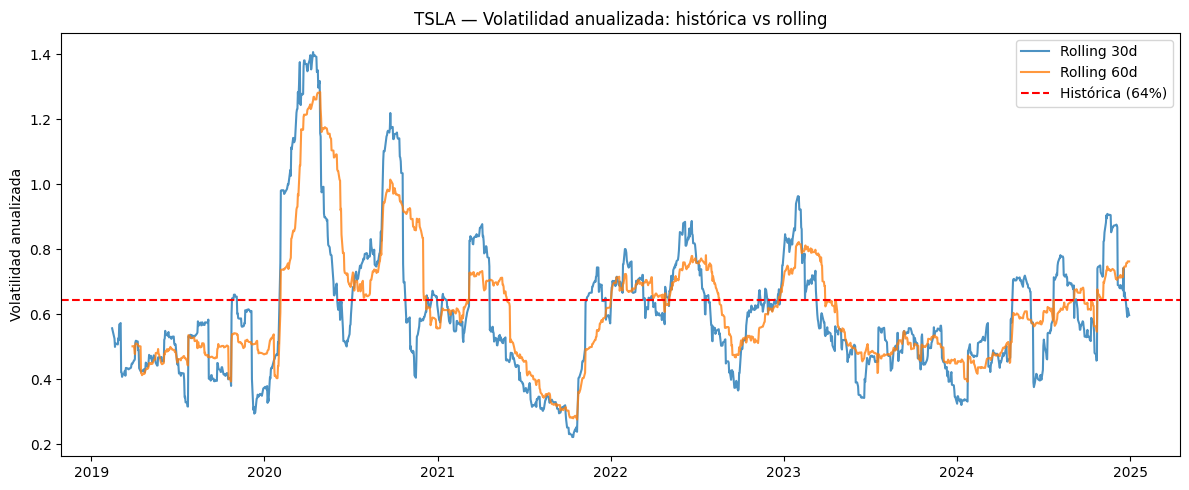


Fecha de máxima volatilidad rolling 30d: 2020-04-13 00:00:00
Volatilidad en ese punto: 140.7%


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

data = yf.download("TSLA", start="2019-01-01", end="2024-12-31")["Close"]
returns_tsla = np.log(data / data.shift(1)).dropna()

# Forzar a Series 1D si viene como DataFrame
if isinstance(returns_tsla, pd.DataFrame):
    returns_tsla = returns_tsla.squeeze()

vol_historica = returns_tsla.std() * np.sqrt(252)
print(f"Volatilidad histórica anualizada: {float(vol_historica)*100:.2f}%")

# 2. Volatilidad rolling (ventanas de 30 y 60 días)
vol_rolling_30 = returns_tsla.rolling(30).std() * np.sqrt(252)
vol_rolling_60 = returns_tsla.rolling(60).std() * np.sqrt(252)

# Gráfica
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(vol_rolling_30, label="Rolling 30d", alpha=0.8)
ax.plot(vol_rolling_60, label="Rolling 60d", alpha=0.8)
ax.axhline(vol_historica, color='red', linestyle='--', 
           label=f"Histórica ({vol_historica*100:.0f}%)")
ax.set_title("TSLA — Volatilidad anualizada: histórica vs rolling")
ax.set_ylabel("Volatilidad anualizada")
ax.legend()
plt.tight_layout()
plt.show()

# Identificar el período más volátil
fecha_max_vol = vol_rolling_30.idxmax()
print(f"\nFecha de máxima volatilidad rolling 30d: {fecha_max_vol}")
print(f"Volatilidad en ese punto: {vol_rolling_30.max()*100:.1f}%")

Calculo del EMWA 

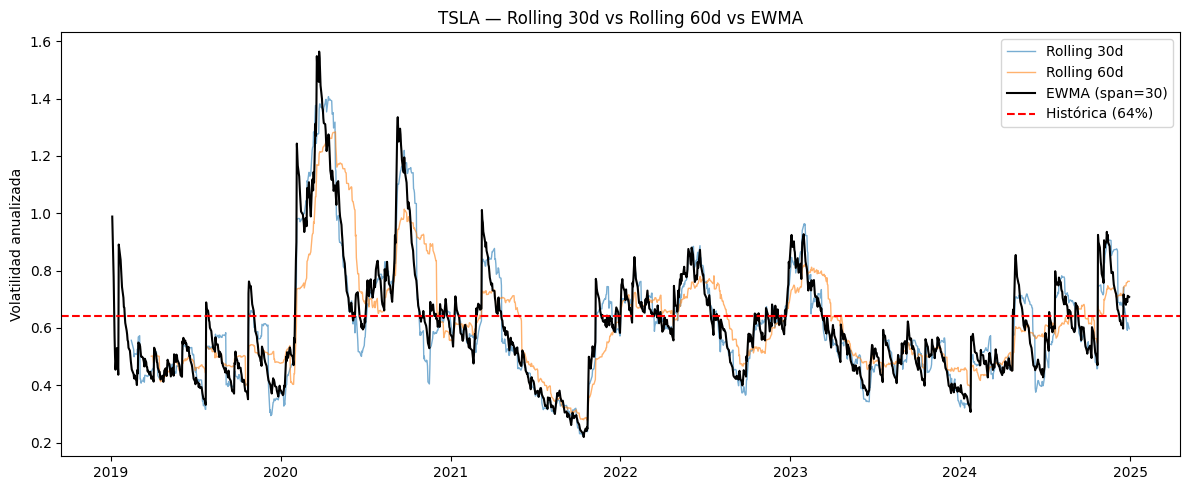

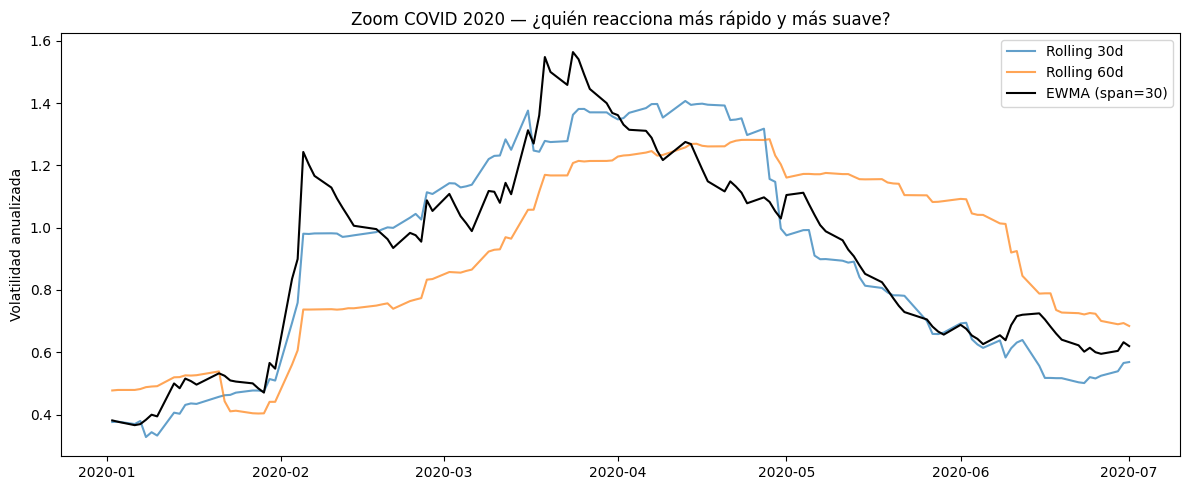

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# EWMA de volatilidad — span=30 da un peso similar al rolling de 30,
# pero pondera exponencialmente en lugar de cortar abruptamente
vol_ewma_30 = returns_tsla.ewm(span=30).std() * np.sqrt(252)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(vol_rolling_30, label="Rolling 30d", alpha=0.6, linewidth=1)
ax.plot(vol_rolling_60, label="Rolling 60d", alpha=0.6, linewidth=1)
ax.plot(vol_ewma_30, label="EWMA (span=30)", color='black', linewidth=1.5)
ax.axhline(vol_historica, color='red', linestyle='--', 
           label=f"Histórica ({float(vol_historica)*100:.0f}%)")

ax.set_title("TSLA — Rolling 30d vs Rolling 60d vs EWMA")
ax.set_ylabel("Volatilidad anualizada")
ax.legend()
plt.tight_layout()
plt.show()

# Zoom al período COVID para ver la diferencia de reactividad
fig, ax = plt.subplots(figsize=(12, 5))
periodo = slice("2020-01-01", "2020-07-01")

ax.plot(vol_rolling_30[periodo], label="Rolling 30d", alpha=0.7)
ax.plot(vol_rolling_60[periodo], label="Rolling 60d", alpha=0.7)
ax.plot(vol_ewma_30[periodo], label="EWMA (span=30)", color='black', linewidth=1.5)

ax.set_title("Zoom COVID 2020 — ¿quién reacciona más rápido y más suave?")
ax.set_ylabel("Volatilidad anualizada")
ax.legend()
plt.tight_layout()
plt.show()

La frontera eficiente

Retornos anualizados (mu) — CORREGIDO:
  AAPL: 24.93%
  AMZN: 16.99%
  GLD: 10.31%
  TSLA: 53.73%

Volatilidad anualizada — CORREGIDO:
  AAPL: 31.66%
  AMZN: 35.97%
  GLD: 15.55%
  TSLA: 67.01%


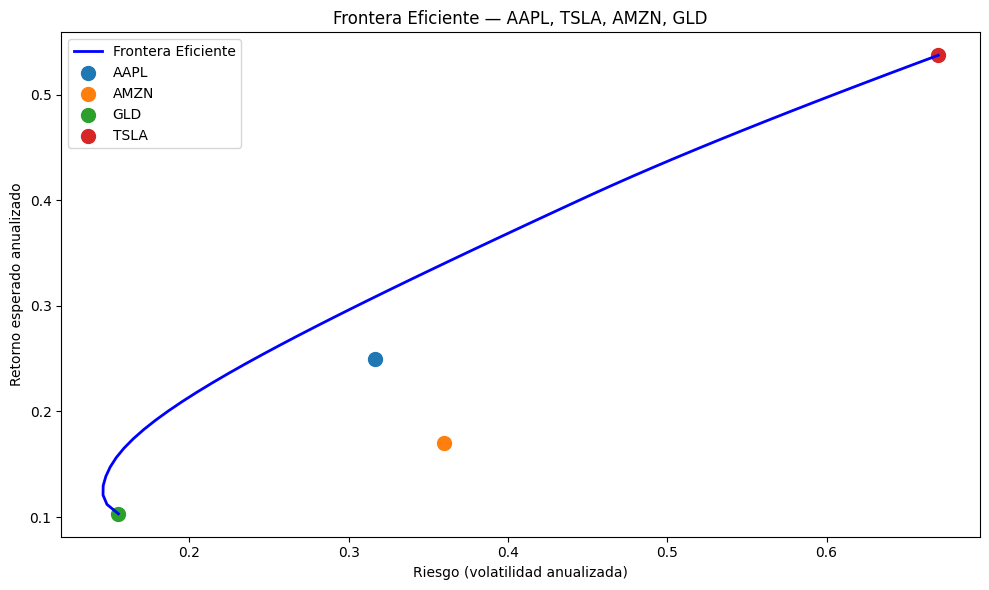

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.optimize import minimize

# Usar el orden REAL de las columnas, no el que escribiste a mano
tickers = returns.columns.tolist()  # ahora siempre está sincronizado

mu = returns.mean().values * 252
Sigma = returns.cov().values * 252

print("Retornos anualizados (mu) — CORREGIDO:")
for ticker, m in zip(tickers, mu):
    print(f"  {ticker}: {m*100:.2f}%")

print("\nVolatilidad anualizada — CORREGIDO:")
for ticker, i in zip(tickers, range(len(tickers))):
    print(f"  {ticker}: {np.sqrt(Sigma[i,i])*100:.2f}%")
n_activos = len(tickers)

def portfolio_stats(w, mu, Sigma):
    ret = w @ mu
    vol = np.sqrt(w @ Sigma @ w)
    return ret, vol

def minimize_vol(w, Sigma):
    return np.sqrt(w @ Sigma @ w)

# Restricciones: pesos suman 1, cada peso entre 0 y 1 (sin shorting)
restricciones = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
bounds = tuple((0, 1) for _ in range(n_activos))
w0 = np.array([1/n_activos] * n_activos)  # punto inicial: equal weight

# Generar la frontera — para cada retorno objetivo, minimizar riesgo
retornos_objetivo = np.linspace(mu.min(), mu.max(), 50)
riesgos_frontera = []

for r_obj in retornos_objetivo:
    restricciones_completas = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'eq', 'fun': lambda w, r_obj=r_obj: w @ mu - r_obj}
    ]
    resultado = minimize(minimize_vol, w0, args=(Sigma,), 
                         method='SLSQP', bounds=bounds, 
                         constraints=restricciones_completas)
    riesgos_frontera.append(resultado.fun)

# Graficar
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(riesgos_frontera, retornos_objetivo, 'b-', linewidth=2, label='Frontera Eficiente')

# Marcar cada activo individual
for i, ticker in enumerate(tickers):
    ax.scatter(np.sqrt(Sigma[i,i]), mu[i], s=100, label=ticker)

ax.set_xlabel('Riesgo (volatilidad anualizada)')
ax.set_ylabel('Retorno esperado anualizado')
ax.set_title('Frontera Eficiente — AAPL, TSLA, AMZN, GLD')
ax.legend()
plt.tight_layout()
plt.show()

In [10]:
print("Retornos anualizados (mu):")
for ticker, m in zip(tickers, mu):
    print(f"  {ticker}: {m*100:.2f}%")

print("\nVolatilidad anualizada (diagonal de Sigma):")
for ticker, i in zip(tickers, range(len(tickers))):
    print(f"  {ticker}: {np.sqrt(Sigma[i,i])*100:.2f}%")
    
print("Columnas de returns (orden real):")
print(returns.columns.tolist())

print("\nOrden de tickers que definiste:")
print(tickers)

Retornos anualizados (mu):
  AAPL: 24.93%
  TSLA: 16.99%
  AMZN: 10.31%
  GLD: 53.73%

Volatilidad anualizada (diagonal de Sigma):
  AAPL: 31.66%
  TSLA: 35.97%
  AMZN: 15.55%
  GLD: 67.01%
Columnas de returns (orden real):
['AAPL', 'AMZN', 'GLD', 'TSLA']

Orden de tickers que definiste:
['AAPL', 'TSLA', 'AMZN', 'GLD']


In [ ]:
def neg_sharpe(w, mu, Sigma, rf=0.04):
    ret, vol = portfolio_stats(w, mu, Sigma)
    return -(ret - rf) / vol

# Portafolio de máximo Sharpe
resultado_sharpe = minimize(neg_sharpe, w0, args=(mu, Sigma),
                            method='SLSQP', bounds=bounds,
                            constraints={'type': 'eq', 'fun': lambda w: np.sum(w) - 1})

w_optimo = resultado_sharpe.x
ret_opt, vol_opt = portfolio_stats(w_optimo, mu, Sigma)

print("Pesos óptimos (máximo Sharpe):")
for ticker, w in zip(tickers, w_optimo):
    print(f"  {ticker}: {w*100:.1f}%")

print(f"\nRetorno esperado: {ret_opt*100:.2f}%")
print(f"Riesgo:           {vol_opt*100:.2f}%")
print(f"Sharpe Ratio:     {(ret_opt-0.04)/vol_opt:.2f}")

Pesos óptimos (máximo Sharpe):
  AAPL: 28.4%
  AMZN: 0.0%
  GLD: 51.1%
  TSLA: 20.5%

Retorno esperado: 23.36%
Riesgo:           22.18%
Sharpe Ratio:     0.87


In [13]:
def minimize_vol_simple(w, Sigma):
    return w @ Sigma @ w  # varianza, no necesitamos la raíz para optimizar

# GMV: minimizar riesgo SIN restricción de retorno objetivo
restricciones_gmv = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}

resultado_gmv = minimize(minimize_vol_simple, w0, args=(Sigma,),
                         method='SLSQP', bounds=bounds,
                         constraints=restricciones_gmv)

w_gmv = resultado_gmv.x
ret_gmv, vol_gmv = portfolio_stats(w_gmv, mu, Sigma)

print("Pesos del portafolio de Mínima Varianza Global:")
for ticker, w in zip(tickers, w_gmv):
    print(f"  {ticker}: {w*100:.1f}%")

print(f"\nRiesgo GMV:        {vol_gmv*100:.2f}%")
print(f"Riesgo GLD solo:   {np.sqrt(Sigma[tickers.index('GLD'), tickers.index('GLD')])*100:.2f}%")

Pesos del portafolio de Mínima Varianza Global:
  AAPL: 12.9%
  AMZN: 4.4%
  GLD: 82.7%
  TSLA: 0.0%

Riesgo GMV:        14.56%
Riesgo GLD solo:   15.55%
